In [9]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from tqdm import tqdm
import os
import gc
import pickle

In [10]:
# 读取数据
clustering_results = pd.read_csv("clustering_results.csv")
tsne_features = pd.read_csv("tsne_features.csv")

print(f"数据形状: {clustering_results.shape}")
print(f"t-SNE特征形状: {tsne_features.shape}")
print(f"K-means cluster数量: {clustering_results['kmeans_cluster'].nunique()}")
print(f"唯一cluster: {sorted(clustering_results['kmeans_cluster'].unique())}")


数据形状: (22248, 8)
t-SNE特征形状: (22248, 4)
K-means cluster数量: 20
唯一cluster: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]


In [11]:
def generate_all_clusters_scatter_pdf():
    """
    生成包含所有cluster的散点图PDF，并在每个cluster位置标注cluster名称
    """
    plt.rcParams['figure.figsize'] = (16, 16)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 14
    
    # 创建PDF文件
    output_path = "all_clusters_scatter_plot.pdf"
    
    # 获取所有唯一的cluster
    unique_clusters = sorted(clustering_results['kmeans_cluster'].unique())
    print(f"找到 {len(unique_clusters)} 个不同的cluster")
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(16, 16))
    
    # 为每个cluster分配不同的颜色
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))
    
    # 计算每个cluster的中心位置用于标注
    cluster_centers = {}
    
    # 绘制每个cluster
    for i, cluster_id in enumerate(unique_clusters):
        cluster_mask = clustering_results['kmeans_cluster'] == cluster_id
        
        if cluster_mask.sum() > 0:
            # 绘制cluster点
            ax.scatter(tsne_features.loc[cluster_mask, 'tSNE1'],
                      tsne_features.loc[cluster_mask, 'tSNE2'],
                      c=[colors[i]], alpha=0.7, s=20, 
                      label=f'Cluster {cluster_id} ({cluster_mask.sum():,} points)')
            
            # 计算cluster中心位置
            center_x = tsne_features.loc[cluster_mask, 'tSNE1'].mean()
            center_y = tsne_features.loc[cluster_mask, 'tSNE2'].mean()
            cluster_centers[cluster_id] = (center_x, center_y)
    
    # 在cluster中心位置添加标注
    for cluster_id, (center_x, center_y) in cluster_centers.items():
        ax.annotate(f'C{cluster_id + 1}', 
                   (center_x, center_y),
                   xytext=(5, 5), textcoords='offset points',
                   fontsize=20, fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                   ha='left')
    
    ax.grid(False)
    

    plt.tight_layout()
    
    with PdfPages(output_path) as pdf:
        pdf.savefig(fig, bbox_inches='tight', dpi=300)
    
    plt.close(fig)
    
    print(f"\nPDF文件已生成: {output_path}")
    return output_path

generate_all_clusters_scatter_pdf()

找到 20 个不同的cluster

PDF文件已生成: all_clusters_scatter_plot.pdf


'all_clusters_scatter_plot.pdf'

In [12]:
# 创建cluster和class_name的交叉表
cluster_class_crosstab = pd.crosstab(clustering_results['kmeans_cluster'], clustering_results['class_name'])
print(f"交叉表形状: {cluster_class_crosstab.shape}")

# 找出每个cluster的主要class（出现次数>=10的class）
cluster_summarize = cluster_class_crosstab.copy()
cluster_summarize[cluster_summarize < 10] = 0
cluster_summarize[cluster_summarize >= 10] = 1

cluster_label = {}
for i in range(len(cluster_summarize)):
    cluster_label[i] = list(cluster_summarize.columns[np.where(cluster_summarize.iloc[i, :] == 1)[0]])


交叉表形状: (20, 1854)


In [13]:
clustering_results = pd.read_csv("clustering_results.csv")
tsne_features = pd.read_csv("tsne_features.csv")
cluster_summarize = pd.crosstab(clustering_results['kmeans_cluster'], clustering_results['class_name'])
cluster_summarize[cluster_summarize < 10] = 0
cluster_summarize[cluster_summarize >= 10] = 1

In [14]:
cluster_label = {}
for i in range(len(cluster_summarize)):
    cluster_label[i] = list(cluster_summarize.columns[np.where(cluster_summarize.iloc[i, :] == 1)[0]])

In [7]:
with open("cluster_label.pkl", 'wb') as f:
    pickle.dump(cluster_label, f)

In [15]:
from scipy.spatial.distance import cdist, pdist
from itertools import combinations

# 合并tsne_features和clustering_results，获取train_eval信息
data = tsne_features.copy()
data['train'] = clustering_results['train']

# 1. 计算同一个class_name内train点和eval点之间的距离
intra_class_distances = []

print("计算类内train-eval距离...")
skipped_classes = 0
for class_name in tqdm(data['class_name'].unique()):
    # 获取同一类别的train点和eval点
    class_data = data[data['class_name'] == class_name]
    train_data = class_data[class_data['train'] == 'train'][['tSNE1', 'tSNE2']].values
    eval_data = class_data[class_data['train'] == 'eval'][['tSNE1', 'tSNE2']].values
    
    if len(train_data) > 0 and len(eval_data) > 0:
        # 计算train点和eval点之间的欧氏距离
        distances = cdist(train_data, eval_data, metric='euclidean')
        intra_class_distances.extend(distances.flatten())
    else:
        skipped_classes += 1

intra_class_distances = np.array(intra_class_distances)

print(f"类内train-eval距离数量: {len(intra_class_distances)}")
print(f"跳过的类别数量（没有train或eval点）: {skipped_classes}")
print(f"类内平均距离: {np.mean(intra_class_distances):.4f}")
print(f"类内距离标准差: {np.std(intra_class_distances):.4f}")
print(f"类内距离中位数: {np.median(intra_class_distances):.4f}")


计算类内train-eval距离...


100%|██████████| 1854/1854 [00:01<00:00, 1008.03it/s]

类内train-eval距离数量: 42274
跳过的类别数量（没有train或eval点）: 0
类内平均距离: 43.9791
类内距离标准差: 32.2454
类内距离中位数: 39.6153


In [9]:
# 2. 计算随机train点和eval点之间的距离（作为对照）
# 为了公平比较，采样相同数量的随机train-eval点对
n_random_samples = len(intra_class_distances)

print(f"\n计算随机train-eval点对距离（采样 {n_random_samples} 对）...")
train_points = data[data['train'] == 'train'][['tSNE1', 'tSNE2']].values
eval_points = data[data['train'] == 'eval'][['tSNE1', 'tSNE2']].values

print(f"Train点数量: {len(train_points)}, Eval点数量: {len(eval_points)}")

# 随机采样train-eval点对
np.random.seed(42)
random_distances = []

for _ in tqdm(range(n_random_samples)):
    # 随机选择一个train点和一个eval点
    idx_train = np.random.choice(len(train_points))
    idx_eval = np.random.choice(len(eval_points))
    distance = np.linalg.norm(train_points[idx_train] - eval_points[idx_eval])
    random_distances.append(distance)

random_distances = np.array(random_distances)

print(f"随机train-eval距离数量: {len(random_distances)}")
print(f"随机平均距离: {np.mean(random_distances):.4f}")
print(f"随机距离标准差: {np.std(random_distances):.4f}")
print(f"随机距离中位数: {np.median(random_distances):.4f}")



计算随机train-eval点对距离（采样 42274 对）...
Train点数量: 17798, Eval点数量: 4450


100%|██████████| 42274/42274 [00:00<00:00, 157408.53it/s]

随机train-eval距离数量: 42274
随机平均距离: 76.0275
随机距离标准差: 35.1292
随机距离中位数: 74.0429


In [10]:
from scipy import stats
t_stat, p_value = stats.ttest_ind(intra_class_distances, random_distances)
print(f"\nt-test结果: t-statistic = {t_stat:.4f}, p-value = {p_value:.4e}")

ks_stat, ks_pvalue = stats.ks_2samp(intra_class_distances, random_distances)
print(f"KS-test结果: KS-statistic = {ks_stat:.4f}, p-value = {ks_pvalue:.4e}")



t-test结果: t-statistic = -138.1846, p-value = 0.0000e+00
KS-test结果: KS-statistic = 0.3507, p-value = 0.0000e+00


In [11]:
fig, ax = plt.subplots(figsize=(3, 3))
distance_df = pd.DataFrame({
    'Distance': np.concatenate([intra_class_distances, random_distances]),
    'Class': ['in-class\ntrain-eval'] * len(intra_class_distances) + ['random\ntrain-eval'] * len(random_distances)
})

sns.violinplot(data=distance_df, x='Class', y='Distance', 
               palette=['#5E9FD1', '#ED7B85'], 
               inner=None, 
               linecolor='black',
               ax=ax)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')
ax.set_ylabel('Distance', fontsize=12)

plt.tight_layout()
plt.savefig('distance_comparison.pdf', dpi=300, bbox_inches='tight')
plt.close()


/tmp/ipykernel_624209/3156402207.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=distance_df, x='Class', y='Distance',


In [12]:
def generate_class_scatter_by_cluster():
    """
    按cluster顺序为每个class_name绘制散点图
    每个图中将目标class标红，其他点为浅灰色
    跳过C1 (cluster 0)
    """
    output_path = "class_scatter_by_cluster.pdf"
    
    # 获取所有cluster（跳过cluster 0，即C1）
    unique_clusters = sorted([c for c in clustering_results['kmeans_cluster'].unique() if c != 1])
    print(f"将处理 {len(unique_clusters)} 个cluster (跳过C1)")
    
    # 统计总共要绘制的图数量
    total_plots = 0
    for cluster_id in unique_clusters:
        if cluster_id in cluster_label and len(cluster_label[cluster_id]) > 0:
            total_plots += len(cluster_label[cluster_id])
    
    print(f"总共将绘制 {total_plots} 个散点图")
    
    # 创建PDF
    with PdfPages(output_path) as pdf:
        plot_count = 0
        
        for cluster_id in tqdm(unique_clusters, desc="处理Cluster"):
            # 检查该cluster是否有主要classes
            if cluster_id not in cluster_label or len(cluster_label[cluster_id]) == 0:
                continue
            
            classes_in_cluster = cluster_label[cluster_id]
            
            # 为该cluster的每个class绘制散点图
            for class_name in classes_in_cluster:
                fig, ax = plt.subplots(figsize=(10, 10))
                
                # 获取该class的点
                class_mask = clustering_results['class_name'] == class_name
                
                # 绘制背景点（其他所有点，浅灰色）
                other_mask = ~class_mask
                ax.scatter(tsne_features.loc[other_mask, 'tSNE1'],
                          tsne_features.loc[other_mask, 'tSNE2'],
                          c='lightgray', alpha=0.3, s=10)
                
                # 绘制目标class的点（红色）
                ax.scatter(tsne_features.loc[class_mask, 'tSNE1'],
                          tsne_features.loc[class_mask, 'tSNE2'],
                          c='red', alpha=0.8, s=40,
                          edgecolors='darkred', linewidths=0)
                
                # 设置标题和标签
                n_points = class_mask.sum()
                ax.set_title(f'Cluster {cluster_id+1} - {class_name} ({n_points} points)', 
                           fontsize=16, fontweight='bold')
                ax.set_xlabel('t-SNE 1', fontsize=14)
                ax.set_ylabel('t-SNE 2', fontsize=14)
                ax.grid(False)
                
                plt.tight_layout()
                pdf.savefig(fig, bbox_inches='tight', dpi=150)
                plt.close(fig)
                
                plot_count += 1
                
                # 定期清理内存
                if plot_count % 50 == 0:
                    gc.collect()
        
        print(f"\n实际绘制了 {plot_count} 个散点图")
    
    print(f"PDF文件已生成: {output_path}")
    return output_path

generate_class_scatter_by_cluster()


将处理 19 个cluster (跳过C1)
总共将绘制 517 个散点图


处理Cluster: 100%|██████████| 19/19 [01:32<00:00,  4.84s/it]


实际绘制了 517 个散点图
PDF文件已生成: class_scatter_by_cluster.pdf


'class_scatter_by_cluster.pdf'

In [4]:
from PIL import Image
import os
import glob

def generate_images_pdf(class_list, images_per_page=13, output_name="class_images.pdf"):
    """
    根据class_list生成图片组合PDF
    
    Parameters:
    -----------
    class_list : list
        类别名称列表，例如: ['aardvark', 'abacus', 'accordion']
    images_per_page : int
        每页显示的图片数量，默认13张
    output_name : str
        输出PDF文件名
    """
    
    image_base_path = "/media/ubuntu/sda/visual_stimuli_pattern/things/object_images"
    
    # 计算布局：对于13张图片，使用4行4列（可容纳16张）
    n_rows = 4
    n_cols = 4
    max_images = n_rows * n_cols
    
    print(f"将为 {len(class_list)} 个类别生成图片")
    
    # 创建PDF
    with PdfPages(output_name) as pdf:
        for class_name in tqdm(class_list, desc="处理类别"):
            class_path = os.path.join(image_base_path, class_name)
            
            if not os.path.exists(class_path):
                print(f"警告: 路径不存在 {class_path}")
                continue
            
            # 获取该类别的所有图片
            image_files = sorted(glob.glob(os.path.join(class_path, "*.jpg")))
            
            if len(image_files) == 0:
                print(f"警告: {class_name} 没有找到图片")
                continue
            
            # 选取前images_per_page张图片
            selected_images = image_files[:images_per_page]
            
            # 创建图形
            fig = plt.figure(figsize=(16, 16))
            
            for idx, img_path in enumerate(selected_images):
                try:
                    img = Image.open(img_path)
                    
                    ax = fig.add_subplot(n_rows, n_cols, idx + 1)
                    ax.imshow(img)
                    ax.axis('off')
                    
                    # 在第一张图片下方添加文件名
                    if idx == 0:
                        ax.set_title(os.path.basename(img_path), fontsize=10)
                    
                except Exception as e:
                    print(f"错误: 无法加载图片 {img_path}: {e}")
                    continue
            
            # 设置总标题
            fig.suptitle(f'{class_name} ({len(selected_images)} images)', 
                       fontsize=20, fontweight='bold', y=0.99)
            
            # 紧密拼接图片，不留空隙
            plt.subplots_adjust(left=0, right=1, top=0.97, bottom=0, wspace=0, hspace=0)
            pdf.savefig(fig, bbox_inches='tight', dpi=150)
            plt.close(fig)
            
            # 定期清理内存
            gc.collect()
    
    print(f"\nPDF文件已生成: {output_name}")
    return output_name


In [5]:
# 示例1：使用简单的类别列表
example_class_list = ['coat', 'jumpsuit', 'apple_tree', 'seesaw', 'chisel',
                      'crowbar', 'dagger', 'fork', 'nutcracker', 'caramel', 
                      'soda', 'limousine', 'gopher', 'gorilla', 'hamster', 
                      'hawk', 'kitten', 'lamb', 'bee', 'beetle', 
                      'bug', 'cocoon', 'grasshopper', 'mosquito', 'tick', 'applesauce']


generate_images_pdf(example_class_list, images_per_page=12, output_name="example_images.pdf")



将为 26 个类别生成图片


处理类别: 100%|██████████| 26/26 [00:14<00:00,  1.74it/s]



PDF文件已生成: example_images.pdf


'example_images.pdf'

In [6]:
def generate_scatter_plots(class_list, output_name="class_scatter_plots.pdf"):
    """
    根据class_list为每个类别生成散点图PDF
    每个图中将目标class标红，其他点为浅灰色
    
    Parameters:
    -----------
    class_list : list
        类别名称列表，例如: ['aardvark', 'abacus', 'accordion']
    output_name : str
        输出PDF文件名
    """
    output_path = output_name
    
    print(f"将为 {len(class_list)} 个类别生成散点图")
    
    # 创建PDF
    with PdfPages(output_path) as pdf:
        for class_name in tqdm(class_list, desc="处理类别"):
            # 检查该类别是否存在
            if class_name not in clustering_results['class_name'].values:
                print(f"警告: 类别 {class_name} 在数据中不存在")
                continue
            
            fig, ax = plt.subplots(figsize=(10, 10))
            
            # 获取该class的点
            class_mask = clustering_results['class_name'] == class_name
            
            # 绘制背景点（其他所有点，浅灰色）
            other_mask = ~class_mask
            ax.scatter(tsne_features.loc[other_mask, 'tSNE1'],
                      tsne_features.loc[other_mask, 'tSNE2'],
                      c='lightgray', alpha=0.3, s=10)
            
            # 绘制目标class的点（红色）
            ax.scatter(tsne_features.loc[class_mask, 'tSNE1'],
                      tsne_features.loc[class_mask, 'tSNE2'],
                      c='red', alpha=0.8, s=40,
                      edgecolors='darkred', linewidths=0)
            
            # 设置标题和标签
            n_points = class_mask.sum()
            ax.set_title(f'{class_name} ({n_points} points)', 
                       fontsize=18, fontweight='bold')
            ax.set_xlabel('t-SNE 1', fontsize=14)
            ax.set_ylabel('t-SNE 2', fontsize=14)
            ax.grid(False)
            
            plt.tight_layout()
            pdf.savefig(fig, bbox_inches='tight', dpi=150)
            plt.close(fig)
            
            # 定期清理内存
            gc.collect()
    
    print(f"\nPDF文件已生成: {output_path}")
    return output_path


In [16]:

generate_scatter_plots(example_class_list, output_name="example_scatter.pdf")



将为 26 个类别生成散点图


处理类别: 100%|██████████| 26/26 [00:05<00:00,  4.43it/s]


PDF文件已生成: example_scatter.pdf


'example_scatter.pdf'

## 计算组内欧氏距离并绘制直方图


In [17]:
from scipy.spatial.distance import pdist

def calculate_intra_class_distances(class_list, plot=True, output_name="intra_class_distances.pdf"):
    """
    计算每个类别内的欧氏距离并绘制直方图
    
    Parameters:
    -----------
    class_list : list
        类别名称列表，例如: ['aardvark', 'abacus', 'accordion']
    plot : bool
        是否绘制直方图
    output_name : str
        输出PDF文件名（仅当plot=True时使用）
    
    Returns:
    --------
    dict : 包含统计信息的字典
        {
            'all_distances': 所有距离的数组,
            'mean': 平均距离,
            'std': 标准差,
            'median': 中位数,
            'per_class_stats': 每个类别的统计信息
        }
    """
    
    all_distances = []
    per_class_stats = {}
    
    print(f"计算 {len(class_list)} 个类别的组内距离...")
    
    for class_name in tqdm(class_list, desc="处理类别"):
        # 检查该类别是否存在
        if class_name not in clustering_results['class_name'].values:
            print(f"警告: 类别 {class_name} 在数据中不存在")
            continue
        
        # 获取该类别的所有点
        class_mask = clustering_results['class_name'] == class_name
        class_data = tsne_features.loc[class_mask, ['tSNE1', 'tSNE2']].values
        
        if len(class_data) > 1:
            # 计算该类别内所有点对之间的欧氏距离
            distances = pdist(class_data, metric='euclidean')
            all_distances.extend(distances)
            
            # 保存该类别的统计信息
            per_class_stats[class_name] = {
                'n_points': len(class_data),
                'n_distances': len(distances),
                'mean': np.mean(distances),
                'std': np.std(distances),
                'median': np.median(distances)
            }
        else:
            print(f"警告: 类别 {class_name} 只有 {len(class_data)} 个点，无法计算距离")
    
    all_distances = np.array(all_distances)
    
    # 计算总体统计
    stats = {
        'all_distances': all_distances,
        'mean': np.mean(all_distances),
        'std': np.std(all_distances),
        'median': np.median(all_distances),
        'min': np.min(all_distances),
        'max': np.max(all_distances),
        'n_distances': len(all_distances),
        'per_class_stats': per_class_stats
    }
    
    print(f"\n总体统计:")
    print(f"  距离数量: {stats['n_distances']}")
    print(f"  平均距离: {stats['mean']:.4f}")
    print(f"  标准差: {stats['std']:.4f}")
    print(f"  中位数: {stats['median']:.4f}")
    print(f"  最小值: {stats['min']:.4f}")
    print(f"  最大值: {stats['max']:.4f}")
    
    # 绘制直方图
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 左图：直方图
        axes[0].hist(all_distances, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        axes[0].axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
        axes[0].axvline(stats['median'], color='orange', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
        axes[0].set_xlabel('欧氏距离', fontsize=12)
        axes[0].set_ylabel('频数', fontsize=12)
        axes[0].set_title(f'组内欧氏距离分布 ({len(class_list)} 个类别)', fontsize=14, fontweight='bold')
        axes[0].legend(fontsize=11)
        axes[0].grid(alpha=0.3)
        
        # 右图：使用seaborn的histplot
        sns.histplot(all_distances, bins=50, kde=True, color='steelblue', ax=axes[1])
        axes[1].axvline(stats['mean'], color='red', linestyle='--', linewidth=2, label=f'Mean: {stats["mean"]:.2f}')
        axes[1].axvline(stats['median'], color='orange', linestyle='--', linewidth=2, label=f'Median: {stats["median"]:.2f}')
        axes[1].set_xlabel('欧氏距离', fontsize=12)
        axes[1].set_ylabel('密度', fontsize=12)
        axes[1].set_title('组内欧氏距离分布（带核密度估计）', fontsize=14, fontweight='bold')
        axes[1].legend(fontsize=11)
        axes[1].grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(output_name, dpi=300, bbox_inches='tight')
        print(f"\n直方图已保存: {output_name}")
        plt.show()
        plt.close()
    
    return stats


计算 514 个类别的组内距离...


处理类别: 100%|██████████| 514/514 [00:00<00:00, 1083.03it/s]



总体统计:
  距离数量: 33924
  平均距离: 17.9019
  标准差: 25.6693
  中位数: 6.5233
  最小值: 0.0041
  最大值: 169.5302


/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 27431 (\N{CJK UNIFIED IDEOGRAPH-6B27}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 27663 (\N{CJK UNIFIED IDEOGRAPH-6C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_635438/3063083065.py:105: UserWarning: Glyph 32452 (\N{CJK UN


直方图已保存: distance_hist.pdf


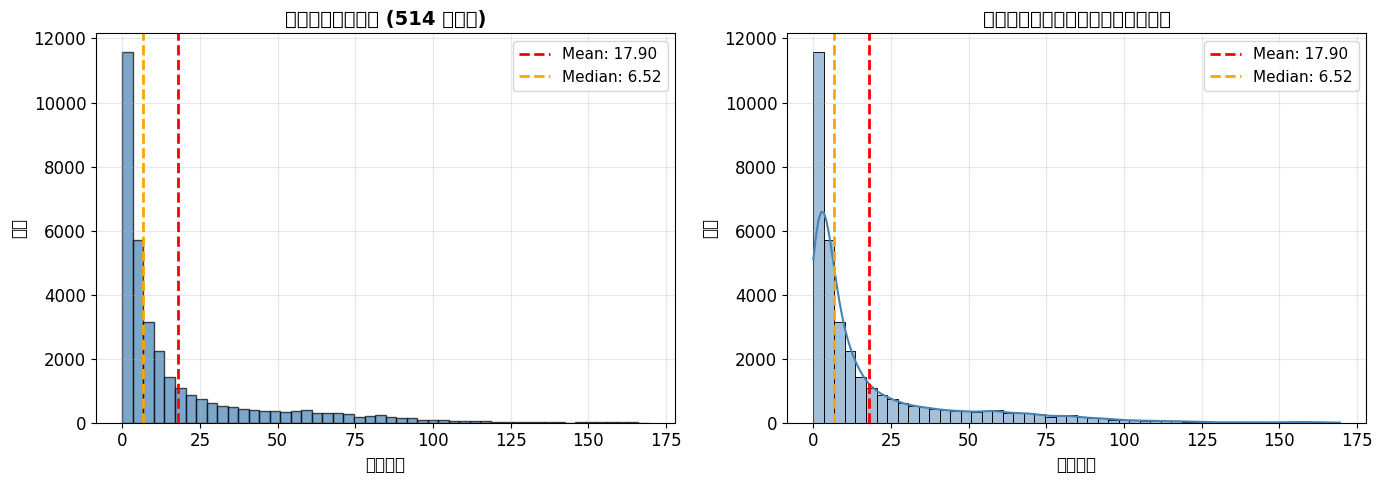

In [18]:

all_classes = []
for cluster_id, classes in cluster_label.items():
    if cluster_id != 0:
        all_classes.extend(classes)

stats = calculate_intra_class_distances(all_classes, plot=True, output_name="distance_hist.pdf")


